In [100]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns 

In [101]:
df=pd.read_csv('train.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [102]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [103]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [104]:
cat_cols=[col for col in df.columns if df[col].dtype=='O']
cat_cols

['Name', 'Sex', 'Ticket', 'Cabin', 'Embarked']

In [105]:
for col in cat_cols:
    print(f'{col} has {df[col].nunique()} unique values')

Name has 891 unique values
Sex has 2 unique values
Ticket has 681 unique values
Cabin has 147 unique values
Embarked has 3 unique values


In [106]:
df['Age'].fillna(df['Age'].median(), inplace=True)



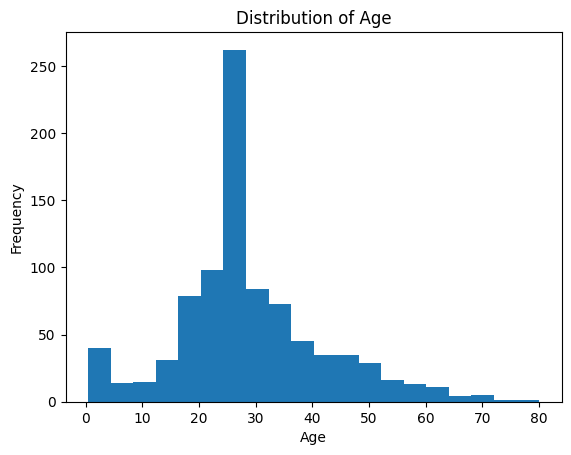

In [107]:
plt.hist(df['Age'],bins=20)
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.title('Distribution of Age')
plt.show()


In [108]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [109]:
df=df.drop(['Name','Cabin','Ticket'],axis=1)


In [110]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
df['Sex']=le.fit_transform(df['Sex'])
df['Embarked']=le.fit_transform(df['Embarked'])
df.head()

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,1,0,3,1,22.0,1,0,7.2500,2
1,2,1,1,0,38.0,1,0,71.2833,0
2,3,1,3,0,26.0,0,0,7.9250,2
3,4,1,1,0,35.0,1,0,53.1000,2
4,5,0,3,1,35.0,0,0,8.0500,2


In [111]:
x=df.drop(['Survived','PassengerId'],axis=1)
y=df['Survived']
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
x_train_scaled=scaler.fit_transform(x_train)
x_test_scaled=scaler.fit_transform(x_test)


In [112]:
#logistic regression
from sklearn.linear_model import LogisticRegression
log_model=LogisticRegression()
log_model.fit(x_train_scaled,y_train)

LogisticRegression()

In [113]:
#KNN
from sklearn.neighbors import KNeighborsClassifier
knn_model=KNeighborsClassifier()
knn_model.fit(x_train_scaled,y_train)

KNeighborsClassifier()

In [114]:
#decision tree
from sklearn.tree import DecisionTreeClassifier
dt_model=DecisionTreeClassifier()
dt_model.fit(x_train_scaled,y_train)

DecisionTreeClassifier()

In [115]:
#Random Forest
from sklearn.ensemble import RandomForestClassifier
rf_model=RandomForestClassifier()
rf_model.fit(x_train_scaled,y_train)

RandomForestClassifier()

In [116]:
#support vector machine
from sklearn.svm import SVC
svm_model=SVC()
svm_model.fit(x_train_scaled,y_train)

SVC()

In [117]:
from sklearn.metrics import accuracy_score
models=[log_model,knn_model,dt_model,rf_model,svm_model]
for model in models:
    y_pred=model.predict(x_test_scaled)
    acc=accuracy_score(y_test,y_pred)
    print(f'{model.__class__.__name__} Accuracy: {acc:.4f}')

LogisticRegression Accuracy: 0.8101
KNeighborsClassifier Accuracy: 0.8212
DecisionTreeClassifier Accuracy: 0.6034
RandomForestClassifier Accuracy: 0.7207
SVC Accuracy: 0.8156


In [118]:
for model in models:
    y_train_pred=model.predict(x_train_scaled)
    train_acc=accuracy_score(y_train,y_train_pred)
    print(f'{model.__class__.__name__} Training Accuracy: {train_acc:.4f}')

LogisticRegression Training Accuracy: 0.8006
KNeighborsClassifier Training Accuracy: 0.8666
DecisionTreeClassifier Training Accuracy: 0.9789
RandomForestClassifier Training Accuracy: 0.9789
SVC Training Accuracy: 0.8441


In [119]:
df_test=pd.read_csv('test.csv')
df_test.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [120]:
df_Test=df_test.drop(['Name','Cabin','Ticket','PassengerId'],axis=1)
df_Test.head()


,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,3,male,34.5,0,0,7.8292,Q
1,3,female,47.0,1,0,7.0000,S
2,2,male,62.0,0,0,9.6875,Q
3,3,male,27.0,0,0,8.6625,S
4,3,female,22.0,1,1,12.2875,S


In [121]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
df_Test['Sex']=le.fit_transform(df_Test['Sex'])
df_Test['Embarked']=le.fit_transform(df_Test['Embarked'])
df_Test.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,3,1,34.5,0,0,7.8292,1
1,3,0,47.0,1,0,7.0000,2
2,2,1,62.0,0,0,9.6875,1
3,3,1,27.0,0,0,8.6625,2
4,3,0,22.0,1,1,12.2875,2


In [125]:
df_Test=df_Test.fillna(df_Test.median())
df_Test.isnull().sum()


Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64

In [126]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
df_Test_scaled=scaler.fit_transform(df_Test)


In [135]:
df_test['Survived']=log_model.predict(df_Test_scaled)

In [138]:
result_df = pd.concat([df_test['PassengerId'], df_test['Survived']], axis=1)
result_df.shape


(418, 2)

In [139]:
result_df.to_csv('result_df.csv', index=False)